In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_absolute_error
from nltk.cluster.kmeans import KMeansClusterer
from nltk.cluster.util import euclidean_distance
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo
# fetch dataset
support2 = fetch_ucirepo(id=880)

import umap.umap_ as umap
import matplotlib.pyplot as plt

from models import *
from my_encodings import *

In [2]:
features = support2.data.features
targets = support2.data.targets

In [3]:
# --------------------------- Initialize dataset ------------------------------
# data (as pandas dataframes)
features = support2.data.features
targets = support2.data.targets


# join together as 1 df for EDA 
df = features.join(targets)
df = df.drop(columns=['death', 'hospdead', 'adlp', 'adls', 'scoma', 'totmcst', 'totcst', 'sps', 'aps', 'hday', \
                      'adlsc', 'prg2m', 'prg6m', 'charges', 'dzgroup', 'dnr', 'dnrday', 'urine',
                      'surv2m', 'surv6m']) # added surv2m, surv6m to drop; prevent data leakage

# drop rows where target = NaN
print(f'Before dropping NaNs in target: {df.shape[0]}')
df = df.dropna(subset=['sfdm2'])

print(f'After dropping NaNs in target: {df.shape[0]}')

# check remaining columns
print(df.columns)
print(len(df.columns))

Before dropping NaNs in target: 9105
After dropping NaNs in target: 7705
Index(['age', 'sex', 'dzclass', 'num.co', 'edu', 'income', 'avtisst', 'race',
       'diabetes', 'dementia', 'ca', 'meanbp', 'wblc', 'hrt', 'resp', 'temp',
       'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'sfdm2'],
      dtype='object')
25


Pipeline for encoding, scaling, and imputing NaNs

1) Separate numerical and categorical features
2) Encode categorical features
3) Split
4) Scale all features (train/test)
5) Impute (train/test)

In [4]:
# -------------------------------------- Encode categorical features ----------------------------------
# isolate categorical features
df_to_encode = df.copy()
numerical_feats = df.select_dtypes(include=['number']).columns.tolist() # determine numerical columns
df_to_encode = df_to_encode.drop(numerical_feats, axis=1) # drop numerical columns

# dummy encode
dum_cols = ['sex', 'dzclass', 'race', 'ca']
df_to_encode = pd.get_dummies(df_to_encode, columns=dum_cols, dtype=int)

# ordinal encoding
income_order = {
    'under $11k': 0,
    '$11-$25k': 1,
    '$25-$50k': 2,
    '>$50k': 3
}

df_to_encode['income'] = df_to_encode['income'].map(income_order)

target_order = {
    'no(M2 and SIP pres)': 0, 
    'adl>=4 (>=5 if sur)': 1, 
    'SIP>=30': 2,
    'Coma or Intub': 3,
    '<2 mo. follow-up': 4    
}

df_to_encode['sfdm2'] = df_to_encode['sfdm2'].map(target_order)

# recombine dataframe
df = pd.concat([df_to_encode, df[numerical_feats]], axis=1)

In [5]:
df.head()

,income,sfdm2,sex_female,sex_male,dzclass_ARF/MOSF,dzclass_COPD/CHF/Cirrhosis,dzclass_Cancer,dzclass_Coma,race_asian,race_black,...,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun
1,1.0,4,1,0,0,1,0,0,0,0,...,34.0,34.59375,98.00000,NaN,NaN,5.500000,132.0,7.250000,NaN,NaN
2,0.0,4,1,0,0,1,0,0,0,0,...,28.0,37.39844,231.65625,NaN,2.199707,2.000000,134.0,7.459961,NaN,NaN
3,0.0,0,1,0,0,0,1,0,0,0,...,32.0,35.00000,NaN,NaN,NaN,0.799927,139.0,NaN,NaN,NaN
4,NaN,0,1,0,1,0,0,0,0,0,...,20.0,37.89844,173.31250,NaN,NaN,0.799927,143.0,7.509766,NaN,NaN
5,NaN,4,0,1,0,0,0,1,0,0,...,44.0,38.39844,266.62500,NaN,NaN,0.699951,140.0,7.659180,NaN,NaN


In [6]:
# -------------------------------------- Split ----------------------------------
X = df.drop(columns=['sfdm2'])
y = df[['sfdm2']]

# split into training vs test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [7]:
# -------------------------------------- Scale all Features ----------------------------------
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

In [8]:
# -------------------------------------- Impute ----------------------------------
imputer = KNNImputer(n_neighbors=10) # initialize imputer 

# training
XS_train = imputer.fit_transform(XS_train) # fit and transform training set 

# testing
XS_test = imputer.transform(XS_test)

In [9]:
train_df = pd.DataFrame(XS_train)
test_df = pd.DataFrame(XS_test)

print(f"Contains missing values xtrain: {train_df.isna().any().any()}")
print(f"Contains missing values xtest: {test_df.isna().any().any()}")
print(f"Contains missing values ytrain: {y_train.isna().any().any()}")
print(f"Contains missing values ytest: {y_test.isna().any().any()}")

Contains missing values xtrain: False
Contains missing values xtest: False
Contains missing values ytrain: False
Contains missing values ytest: False


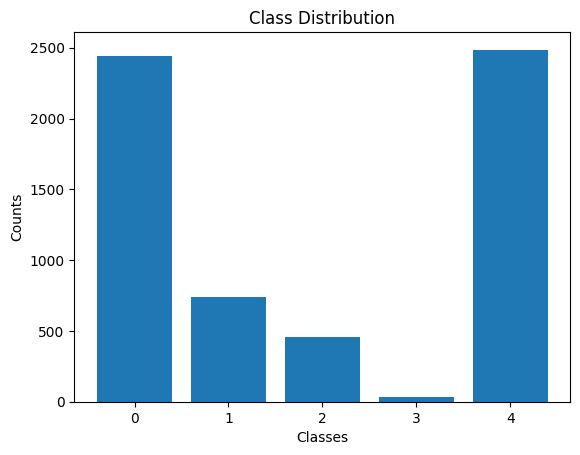

In [10]:
# observe class distribution
y_train_observe = y_train.squeeze()

counts = y_train_observe.value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.title("Class Distribution")
plt.show()

In [11]:
y_train_observe.value_counts()

sfdm2
4    2486
0    2445
1     743
2     454
3      36
Name: count, dtype: int64

### No PCA

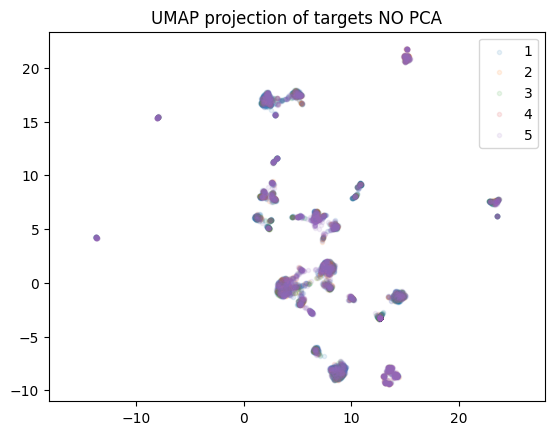

In [12]:
newXY = umap.UMAP().fit_transform(XS_train)

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets NO PCA')
plt.legend()
plt.show()

---------------------------- MN LOGISTIC REGRESSION ----------------------------
training accuracy: 60.82%
testing accuracy: 61.84%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.64', 1: '1.77', 2: '1.73', 3: '1.61', 4: '1.58'}


/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


---------------------------- GAUSSIAN MM ----------------------------
{'MAX ENTROPY': 2.321928094887362, 0: '1.80', 1: 'nan', 2: '1.64', 3: 'nan', 4: 'nan'}


/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: divide by zero encountered in log2
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))
/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: invalid value encountered in multiply
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))


---------------------------- NAIVE BAYES ----------------------------
training accuracy: 24.11%
testing accuracy: 25.57%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.57', 1: '1.65', 2: '1.71', 3: '1.68', 4: '1.32'}


/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


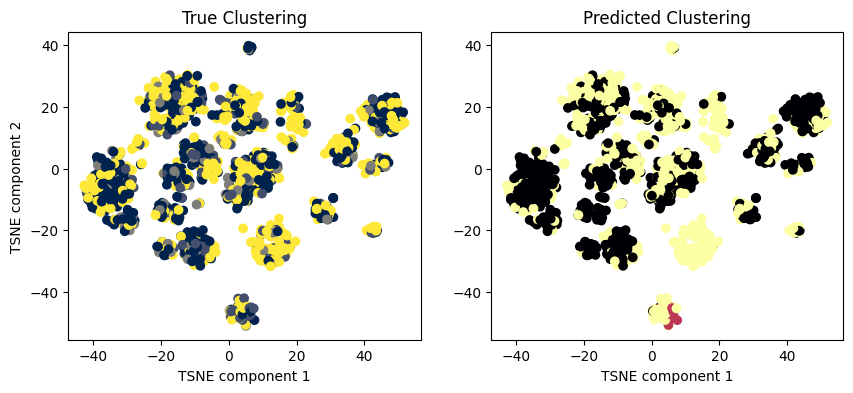

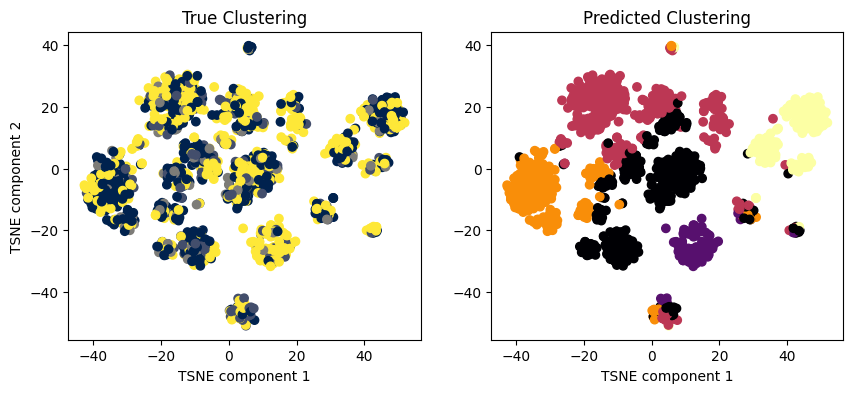

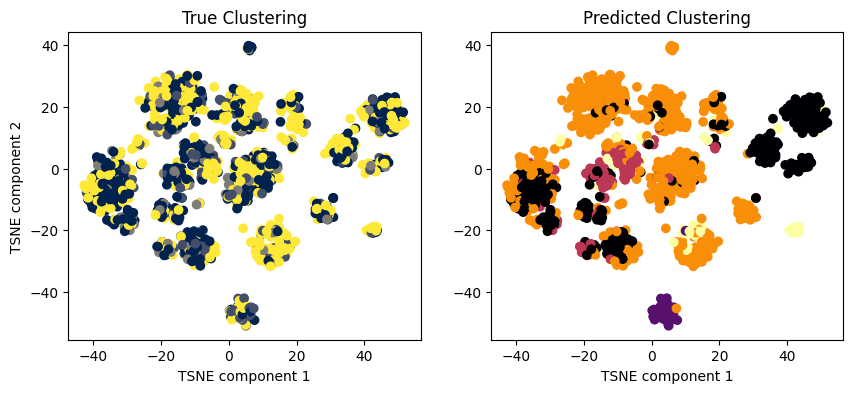

In [13]:
# WITHOUT PCA

print(f'---------------------------- MN LOGISTIC REGRESSION ----------------------------')
MN_LogReg = MN_Logistic_Regression_model(num_classes=5,
                                         x_train=XS_train,
                                         y_train=y_train,
                                         x_test=XS_test,
                                         y_test=y_test)

print(MN_LogReg.get_accuracies())
print(MN_LogReg.get_entropy())
MN_LogReg.visualize_clustering()


print(f'---------------------------- GAUSSIAN MM ----------------------------')
GMM = Gaussian_Mixture_model(num_components=5,
                             rand_state=0,
                             x_data=XS_test,
                             y_data=y_test,
                             target='sfdm2')

print(GMM.get_entropy())
GMM.visualize_clustering()

print(f'---------------------------- NAIVE BAYES ----------------------------')
NB = Naive_Bayes_model(num_classes=5,
                        x_train=XS_train,
                        y_train=y_train,
                        x_test=XS_test,
                        y_test=y_test)

print(NB.get_accuracies())
print(NB.get_entropy())
NB.visualize_clustering()

### PCA fit data

Eigenvalues and explained variance ratio:
  PC1: eigenvalue = 3.0451, explains 9.5% of variance
  PC2: eigenvalue = 2.7060, explains 8.5% of variance
  PC3: eigenvalue = 2.1455, explains 6.7% of variance
  PC4: eigenvalue = 1.9646, explains 6.2% of variance
  PC5: eigenvalue = 1.6373, explains 5.1% of variance
  PC6: eigenvalue = 1.4799, explains 4.6% of variance
  PC7: eigenvalue = 1.4003, explains 4.4% of variance
  PC8: eigenvalue = 1.3232, explains 4.1% of variance
  PC9: eigenvalue = 1.1839, explains 3.7% of variance
  PC10: eigenvalue = 1.1192, explains 3.5% of variance
  PC11: eigenvalue = 1.0743, explains 3.4% of variance
  PC12: eigenvalue = 1.0396, explains 3.3% of variance
  PC13: eigenvalue = 1.0169, explains 3.2% of variance
  PC14: eigenvalue = 1.0013, explains 3.1% of variance
  PC15: eigenvalue = 0.9742, explains 3.1% of variance
  PC16: eigenvalue = 0.9079, explains 2.8% of variance
  PC17: eigenvalue = 0.8511, explains 2.7% of variance
  PC18: eigenvalue = 0.8285, exp

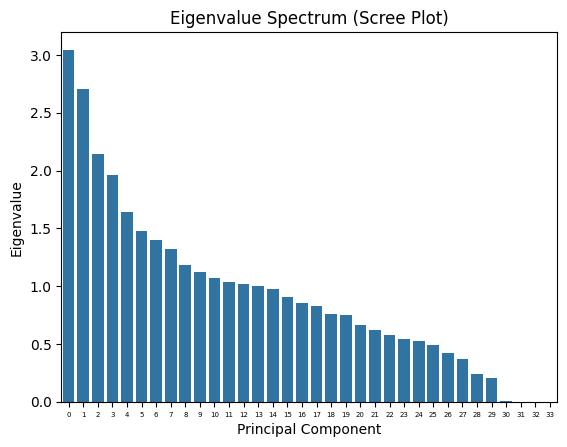

In [14]:
pca = PCA()
pca.fit(XS_train)

# Get eigenvalues (explained variance)
eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

print("Eigenvalues and explained variance ratio:")
for i, (ev, ratio) in enumerate(zip(eigenvalues, explained_ratio)):
    print(f"  PC{i+1}: eigenvalue = {ev:.4f}, explains {ratio*100:.1f}% of variance")
    
print(f"\nTotal variance explained: {sum(explained_ratio)*100:.1f}%")

# Scree plot
sns.barplot(x=range(len(eigenvalues)), y=eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectrum (Scree Plot)')
plt.xticks(fontsize=5)
plt.show()

In [15]:
pca = PCA(n_components=0.97)
X_train_pca = pca.fit_transform(XS_train)
X_test_pca = pca.transform(XS_test)

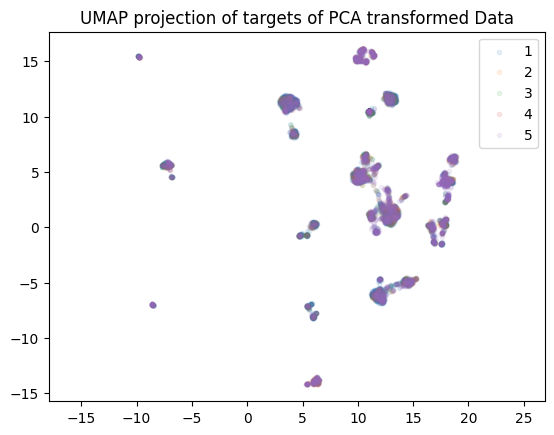

In [16]:
newXY = umap.UMAP().fit_transform(X_train_pca)

for i in range(np.max(y_train) + 1): 
    idx = np.argwhere(y_train == i)
    plt.scatter(newXY[idx, 0], newXY[idx, 1], marker = '.', 
                alpha = 0.1, label = str(i + 1))
    
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of targets of PCA transformed Data')
plt.legend()
plt.show()

/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


training accuracy: 60.97%
testing accuracy: 61.45%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.64', 1: '1.76', 2: '1.73', 3: '1.64', 4: '1.59'}


/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: divide by zero encountered in log2
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))
/Users/anika/MSSE Spring 2026/Chem-277A/277A_Final_Project/models.py:43: RuntimeWarning: invalid value encountered in multiply
  cluster_entropy = float(-np.sum(cluster_probabilities * np.log2(cluster_probabilities)))


{'MAX ENTROPY': 2.321928094887362, 0: '1.72', 1: 'nan', 2: 'nan', 3: 'nan', 4: '1.67'}


/Users/anika/miniconda3/envs/MSSE_python/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


training accuracy: 53.41%
testing accuracy: 54.12%
None
{'MAX ENTROPY': 2.321928094887362, 0: '1.65', 1: '1.79', 2: '1.76', 3: '1.53', 4: '1.55'}


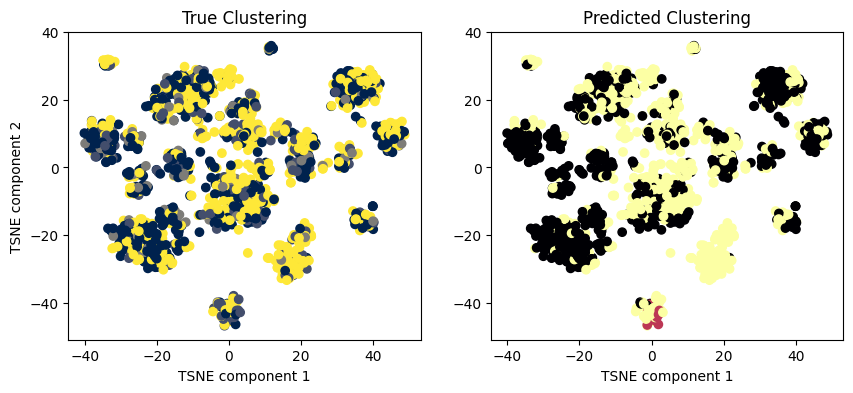

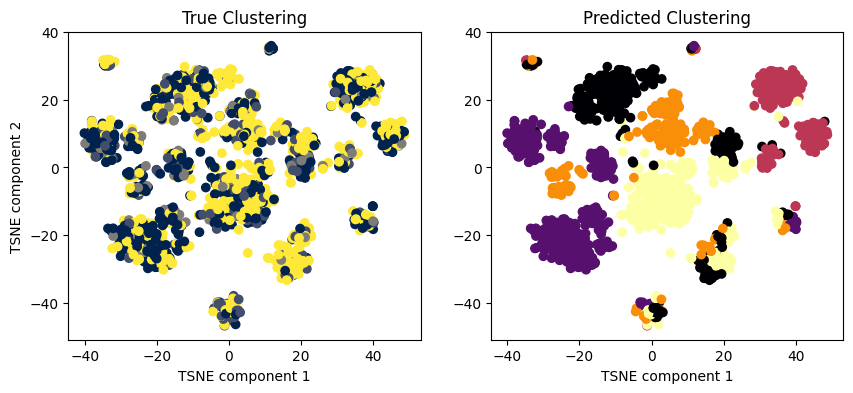

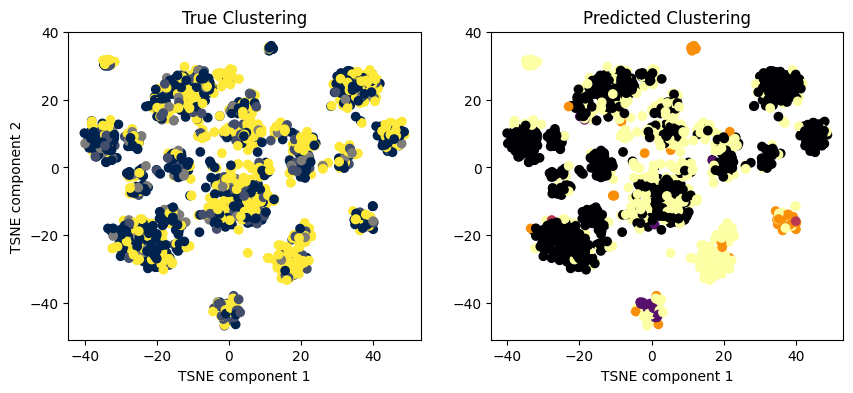

In [17]:
# testing multinomial log regression
MN_LogReg = MN_Logistic_Regression_model(num_classes=5,
                                         x_train=X_train_pca,
                                         y_train=y_train,
                                         x_test=X_test_pca,
                                         y_test=y_test)

print(MN_LogReg.get_accuracies())
print(MN_LogReg.get_entropy())
MN_LogReg.visualize_clustering()

# unsupervised GMM
GMM = Gaussian_Mixture_model(num_components=5,
                             rand_state=0,
                             x_data=X_test_pca,
                             y_data=y_test,
                             target='sfdm2')

print(GMM.get_entropy())
GMM.visualize_clustering()

# supervised naive bayes
NB = Naive_Bayes_model(num_classes=5,
                        x_train=X_train_pca,
                        y_train=y_train,
                        x_test=X_test_pca,
                        y_test=y_test)


print(NB.get_accuracies())
print(NB.get_entropy())
NB.visualize_clustering()